In [7]:
from config import NAVY, RED, GREY, BG

In [8]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///data/creditrisk.db')
df = pd.read_sql('SELECT * FROM german_credit', engine)

print(df.shape)
df.head()

(1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


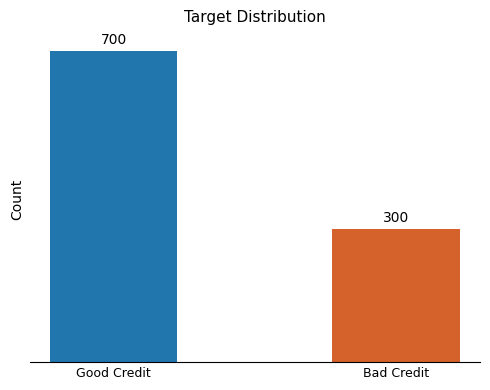

target
1    700
2    300
Name: count, dtype: int64


In [14]:
import matplotlib as mpl
mpl.rcParams.update({
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : True,
    'axes.spines.bottom': True,
    'axes.grid'         : False,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'font.family'       : 'sans-serif',
    'axes.titlesize'    : 11,
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'axes.titlepad'     : 10,
})
BLUE   = '#2176AE'
ORANGE = '#D4622A'

import matplotlib.pyplot as plt

target_counts = df['target'].value_counts().sort_index()
labels = {1: 'Good Credit', 2: 'Bad Credit'}
colors = [BLUE, ORANGE]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    [labels[k] for k in target_counts.index],
    target_counts.values,
    color=colors,
    width=0.45,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=10
    )
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.tick_params(axis='x', length=0)
plt.tight_layout()
plt.show()
print(target_counts)


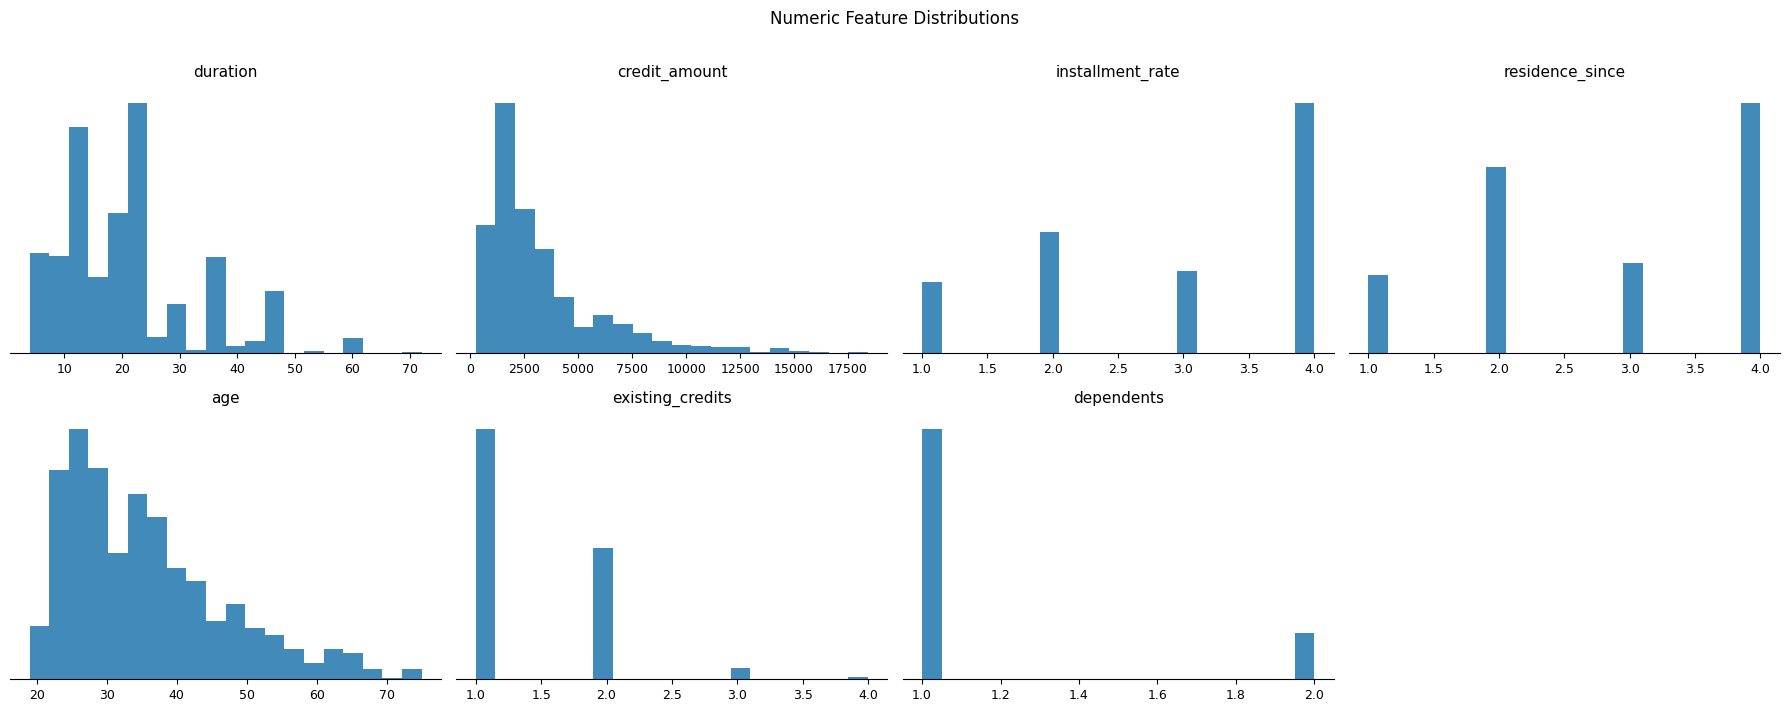

In [13]:
numeric_cols = df.select_dtypes(include='number').columns.drop('target')

n = len(numeric_cols)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color=BLUE, alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].spines['left'].set_visible(False)
    axes[i].set_yticks([])

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric Feature Distributions', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


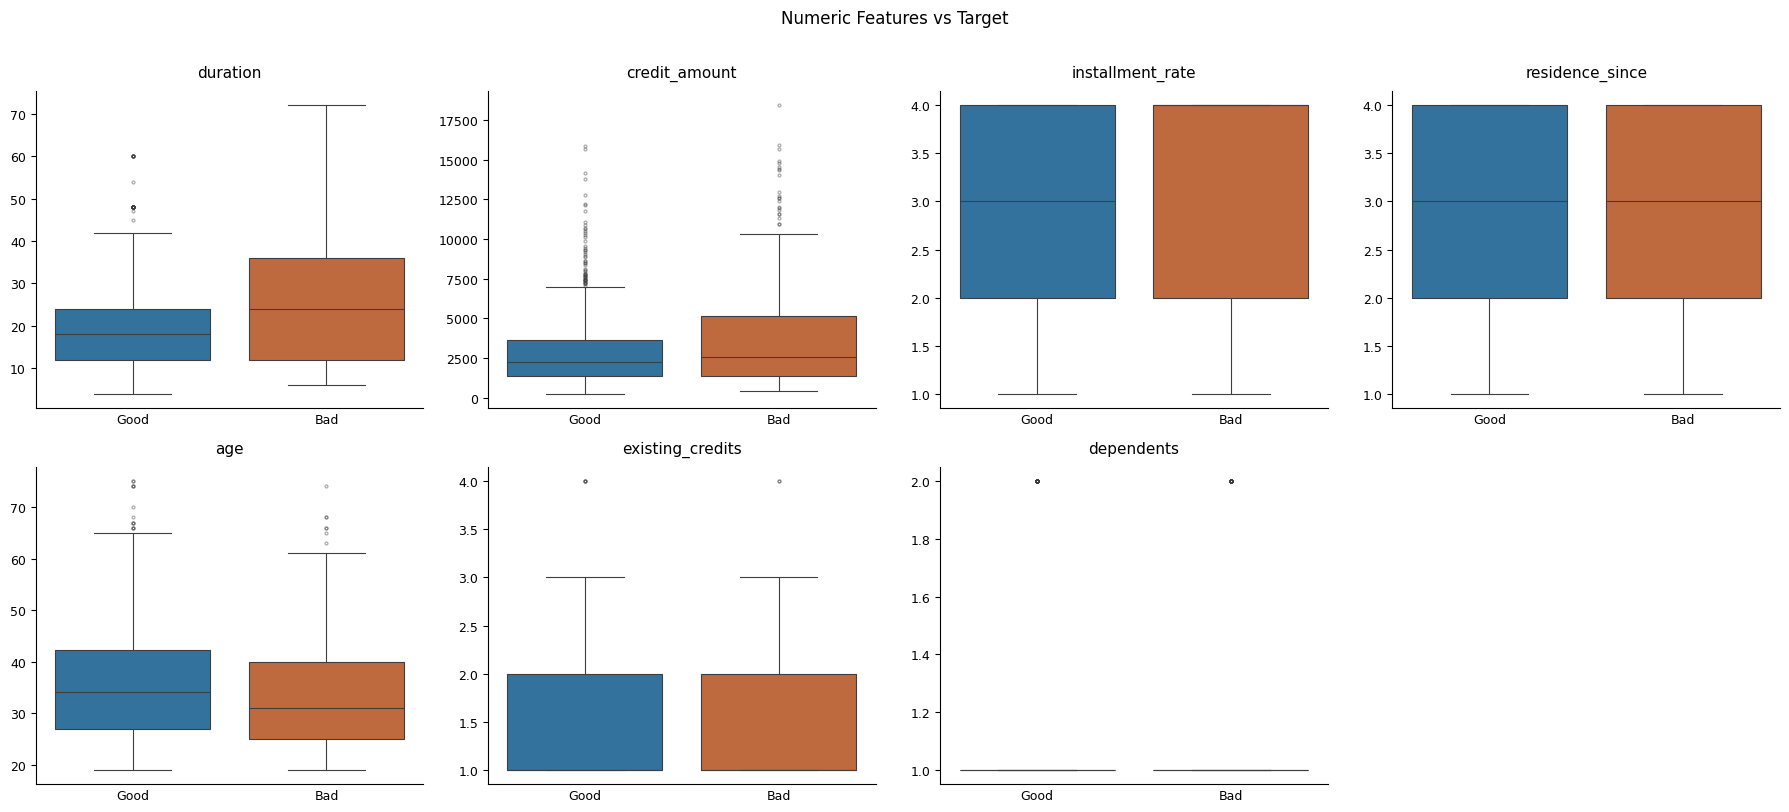

In [11]:
import seaborn as sns

df['target_label'] = df['target'].map({1: 'Good', 2: 'Bad'})

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x='target_label', y=col, data=df, ax=axes[i],
        hue='target_label',
        palette={'Good': BLUE, 'Bad': ORANGE},
        legend=False,
        linewidth=0.8,
        flierprops=dict(marker='o', markersize=2, alpha=0.4),
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', length=0)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric Features vs Target', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


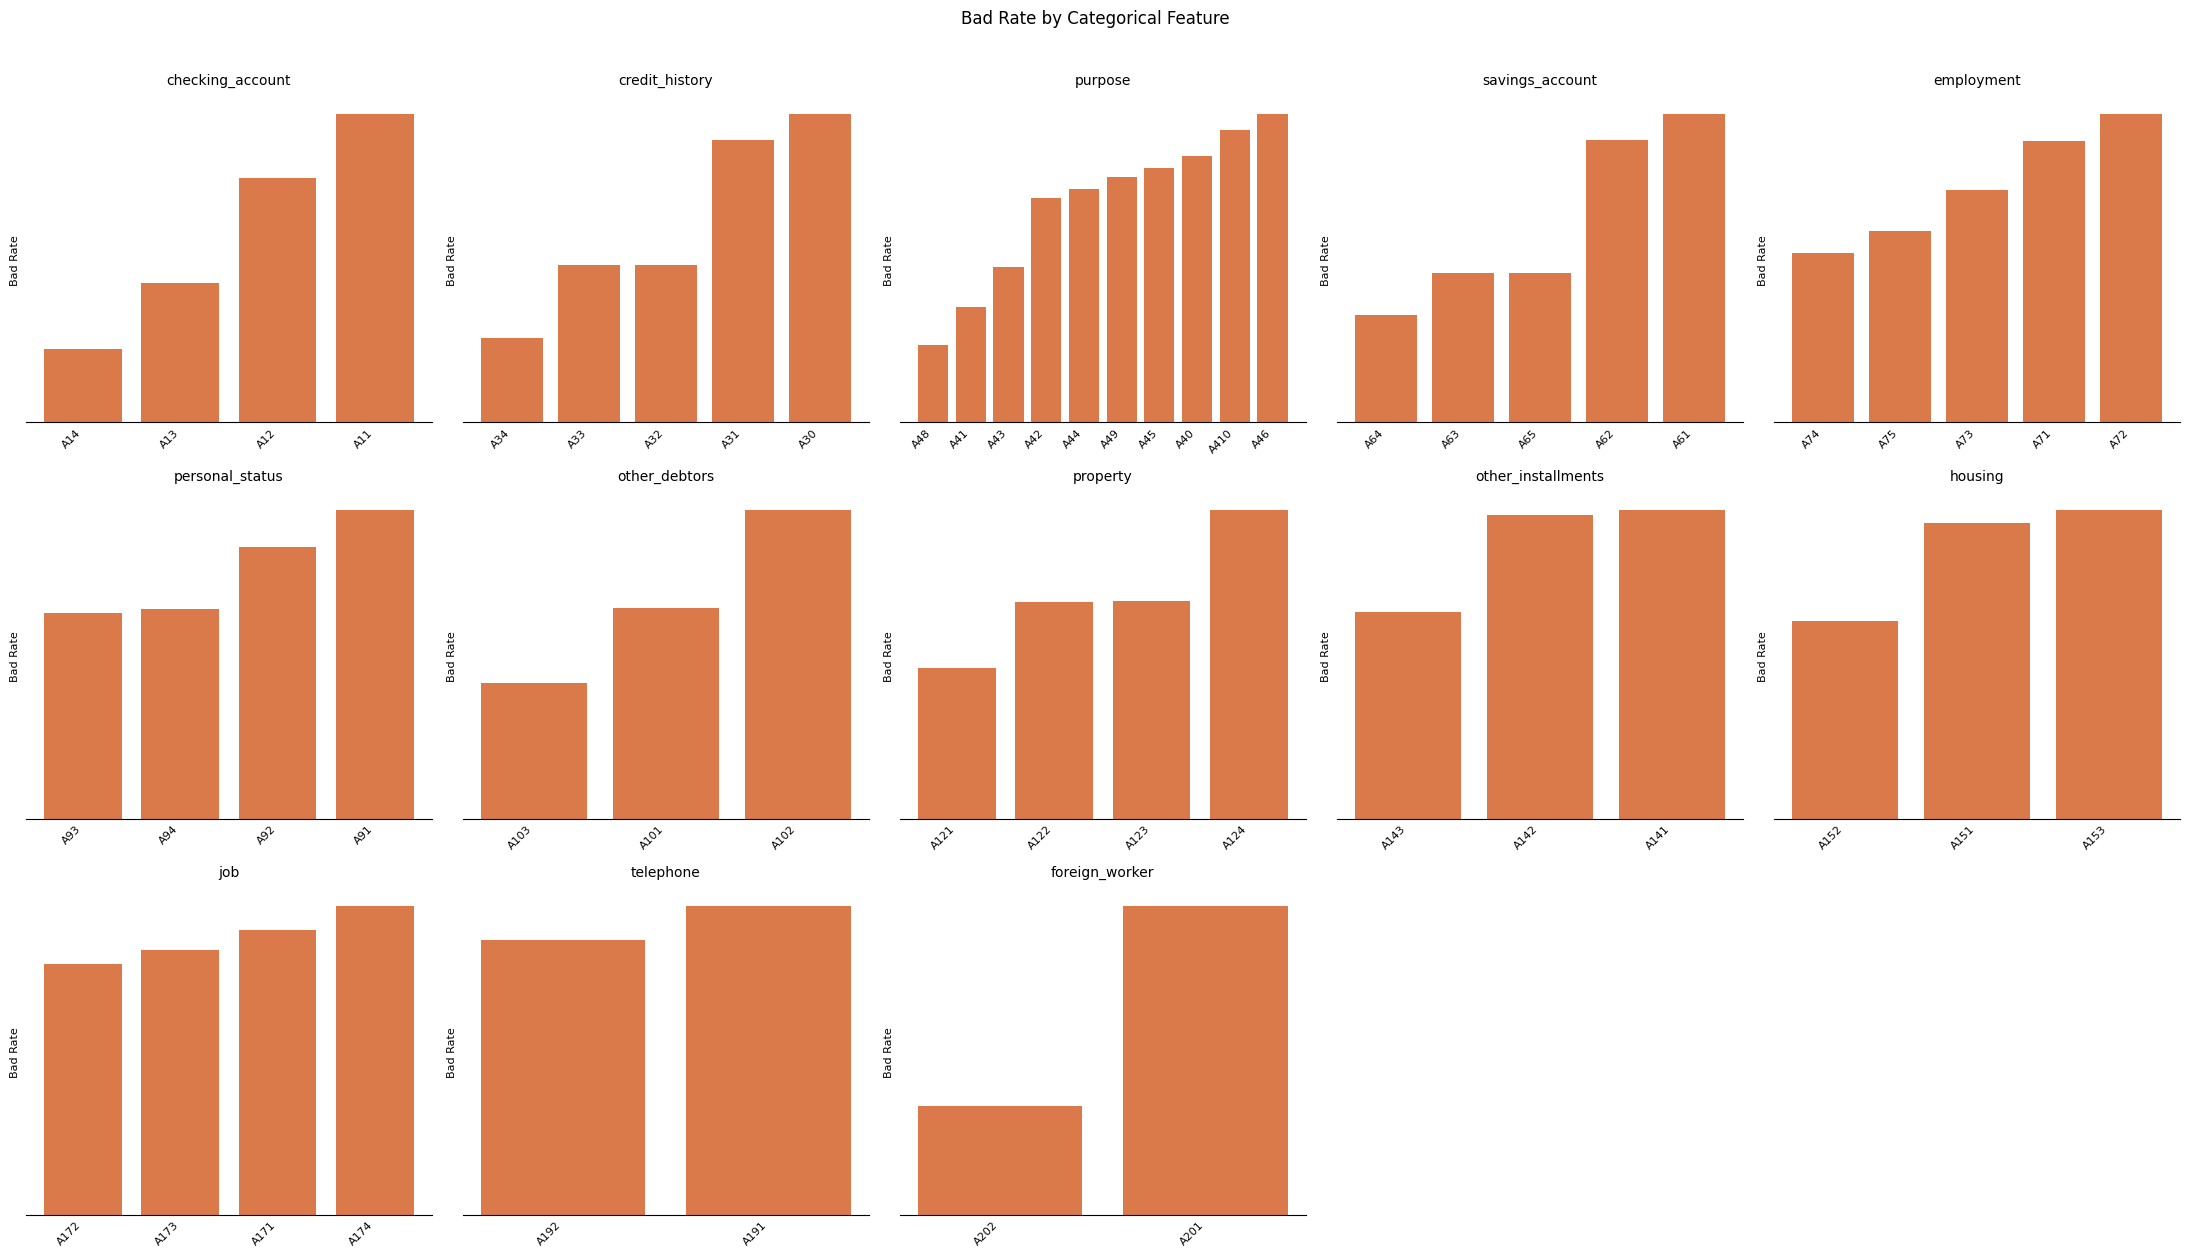

In [12]:
cat_cols = df.select_dtypes(include='object').columns.drop('target_label')

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    bad_rate = df.groupby(col)['target'].apply(lambda x: (x == 2).mean())
    bad_rate = bad_rate.sort_values()
    axes[i].bar(range(len(bad_rate)), bad_rate.values, color=ORANGE, alpha=0.85)
    axes[i].set_xticks(range(len(bad_rate)))
    axes[i].set_xticklabels(
        bad_rate.index,
        rotation=45, ha='right', fontsize=8
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Bad Rate', fontsize=8)
    axes[i].spines['left'].set_visible(False)
    axes[i].set_yticks([])
    axes[i].tick_params(axis='x', length=0)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Bad Rate by Categorical Feature', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()
